In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score

import optuna
import mne

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
def normalize_tfr_robust(X, eps=1e-8):
    """
    Робастная нормализация TFR:
    - вместо среднего — медиана
    - вместо std — IQR (q75 - q25)
    - результат приводится к диапазону [0, 1]

    X shape: (N, C, F, T)
    Нормировка считается по train:
    медиана/квантили берутся по N и T → остаются (C, F)
    """

    # Медиана по trial и времени → (1, C, F, 1)
    median = np.median(X, axis=(0, 3), keepdims=True)

    # Квантили для IQR (робастной шкалы)
    q25 = np.percentile(X, 25, axis=(0, 3), keepdims=True)
    q75 = np.percentile(X, 75, axis=(0, 3), keepdims=True)
    iqr = (q75 - q25) + eps

    # Нормировка:
    # при медиана → 0.5, q25→0, q75→1
    X_norm = (X - median) / iqr + 0.5

    # Жёсткое ограничение диапазона
    # X_norm = np.clip(X_norm, 0.0, 1.0)

    return X_norm

In [3]:
class TFRDataset(Dataset):
    def __init__(self, X, y, time_crop=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.time_crop = time_crop  # int или None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]  # (C,F,T)
        if self.time_crop is not None:
            C, F, T = x.shape
            tc = self.time_crop
            if tc < T:
                t0 = torch.randint(0, T - tc + 1, (1,)).item()
                x = x[:, :, t0:t0+tc]
        return x, self.y[idx]

In [4]:
# ---- train/eval helpers ----

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)

        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        n += x.size(0)
    return total_loss / n


@torch.no_grad()
def eval_one_epoch_f1_macro(model, loader, device):
    model.eval()
    total_loss = 0.0
    n = 0

    all_pred = []
    all_true = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * x.size(0)
        n += x.size(0)

        pred = logits.argmax(dim=1)
        all_pred.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())

    val_loss = total_loss / n
    y_pred = np.concatenate(all_pred)
    y_true = np.concatenate(all_true)

    f1m = f1_score(y_true, y_pred, average="macro")
    return val_loss, f1m

In [5]:
class AlexNetTFR(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, dropout: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=(5,11), stride=(1,4), padding=(2,0)),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,3), stride=(2,2)),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,3), stride=(2,2)),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.adapt = nn.AdaptiveAvgPool2d((4, 8))  # фиксируем размер
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 * 4 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adapt(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [6]:
def loss_slope(losses):
    # линейный тренд: loss ~ a*epoch + b, хотим a < 0, и чем меньше (более отрицательно) — тем лучше
    e = np.arange(len(losses), dtype=np.float64)
    return float(np.polyfit(e, np.array(losses, dtype=np.float64), 1)[0])

In [7]:

def make_multi_objective(
    X, y,
    test_size,
    seed,
    device,
    ModelCls,
    in_channels=7,
    num_classes=2,
    max_epochs=30,
    patience=6,
    cv=False,                 # None/0 -> holdout, int -> kfold, или объект Splitter
    cv_aggregate="median",     # "mean" | "median"
):


    X = np.asarray(X)
    y = np.asarray(y)

    # --- заранее готовим сплиты внутри генератора ---
    if cv:
        # cv может быть числом (k) или готовым splitter-объектом
        splitter = StratifiedKFold(n_splits=max(2, int(round(1/test_size))), shuffle=True, random_state=seed)
        splits = []
        for fold_id, (tr_idx, va_idx) in enumerate(splitter.split(X, y)):
            splits.append((f"fold{fold_id}", X[tr_idx], y[tr_idx], X[va_idx], y[va_idx]))
    else:
        X_train, X_val, y_train, y_val = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
            stratify=y
        )
        splits = [("holdout", X_train, y_train, X_val, y_val)]

    def objective(trial):
        lr = trial.suggest_float("lr", 1e-5, 3e-3, log=True)
        wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.7)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

        crop_on = trial.suggest_categorical("time_crop_on", [0, 1])
        time_crop = None

        fold_best_f1s = []
        fold_slope = []
        fold_curves = []  # чтобы сохранять кривые по каждому фолду

        # --- прогоняем все сплиты (1 holdout или K фолдов) ---
        for fold_id, (split_name, X_train, y_train, X_val, y_val) in enumerate(splits):
            if crop_on:
                # X_train shape: (N, C, F, T) -> time dim = 3
                time_crop = trial.suggest_int("time_crop", 200, X_train.shape[3])

            train_ds = TFRDataset(X_train, y_train, time_crop=time_crop)
            val_ds   = TFRDataset(X_val,   y_val,   time_crop=None)

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

            model = ModelCls(in_channels=in_channels, num_classes=num_classes, dropout=dropout).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

            bad = 0
            best_f1 = -1.0
            train_losses, val_losses, val_f1s = [], [], []

            for epoch in range(max_epochs):
                tr_loss = train_one_epoch(model, train_loader, optimizer, device)
                va_loss, va_f1 = eval_one_epoch_f1_macro(model, val_loader, device)

                train_losses.append(tr_loss)
                val_losses.append(va_loss)
                val_f1s.append(va_f1)

                if va_f1 > best_f1:
                    best_f1 = va_f1
                    bad = 0
                else:
                    bad += 1
                    if bad >= patience:
                        break
            
            # ### Если посходит быстрый выброс из кроссвалидации. то прерывание происходит по вине прунинга
            # trial.report(best_f1, step=fold_id)
            # if trial.should_prune():
            #     raise optuna.TrialPruned()
            # Прунинг в мультиобджектив не работает (

            # slope по хвосту (стабильнее)
            tail = val_losses[-10:] if len(val_losses) >= 10 else val_losses
            slope = loss_slope(tail)

            fold_best_f1s.append(best_f1)
            fold_slope.append(slope)
            fold_curves.append({
                "split": split_name,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "val_f1s": val_f1s,
            })

        # --- агрегируем метрику по фолдам ---
        if cv_aggregate == "median":
            score = (float(np.median(fold_best_f1s)), float(np.median(fold_slope)))
        else:
            score = (float(np.mean(fold_best_f1s)), float(np.mean(fold_slope)))

        # сохраним детали
        trial.set_user_attr("fold_best_f1s", fold_best_f1s)
        trial.set_user_attr("fold_curves", fold_curves)
        trial.set_user_attr("cv_mode", "holdout" if (cv is None or cv == 0) else "kfold")

        return score[0], score[1]

    return objective


In [8]:
def constraints_func(trial):
    f1, slope = trial.values
    return [slope]   # constraint: slope <= 0


In [9]:
time_frequency_file = "../tfr_s10.fif"
tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]
min_f, max_f, min_t, max_t = 5, 30, 100, -500
y = np.where(tfr.events[:, 2] == 9, 1, 0)
X = normalize_tfr_robust(tfr.copy().crop(tmin=0.0, tmax=1.0).data)[:, :, min_f:max_f, min_t:max_t]
device = "cuda" if torch.cuda.is_available() else "cpu"

Reading ../tfr_s10.fif ...


/tmp/ipykernel_1534496/2521578396.py:2: RuntimeWarning: This filename (../tfr_s10.fif) does not conform to MNE naming conventions. All tfr files should end with -tfr.h5 or _tfr.h5
  tfr = mne.time_frequency.read_tfrs(time_frequency_file)[0]


Not setting metadata


In [10]:
max_epochs = 100
num_classes = 2
channels = X.shape[1]
seed = 42
test_size = 0.2
n_trials_optuna_whole = 100
n_startup_trials, n_warmup_steps = 5, 5

In [11]:
sampler = optuna.samplers.NSGAIISampler(
    seed=seed,
    constraints_func=constraints_func,   # <-- сюда
)

study = optuna.create_study(
    directions=["maximize", "minimize"],
    # sampler=optuna.samplers.TPESampler(), для сингл обджектива
    sampler=optuna.samplers.NSGAIISampler()
    # pruner=optuna.pruners.MedianPruner(n_startup_trials=n_startup_trials, n_warmup_steps=n_warmup_steps) # может вызвать ошибки, так как прунер настроен на одиночную метрику
)

objective = make_multi_objective(
    X, 
    y, 
    test_size, 
    seed, 
    device = device,
    ModelCls = AlexNetTFR,   # твой класс модели
    in_channels = channels,
    num_classes = num_classes,
    max_epochs = max_epochs,
    cv =True
)

study.optimize(objective, n_trials=n_trials_optuna_whole, show_progress_bar=True)

pareto = study.best_trials
print("Pareto trials:", len(pareto))

for t in pareto[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")

/home/asma.benachour/miniconda3/envs/brainbert/lib/python3.10/site-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-01-14 17:05:16,096] A new study created in memory with name: no-name-1e567b13-a5cf-415b-8871-5644d575f02e


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-01-14 17:05:27,553] Trial 0 finished with values: [0.6451703745423825, 0.01754273265763058] and parameters: {'lr': 3.178054060421334e-05, 'weight_decay': 3.878267487334755e-06, 'dropout': 0.09357155616658336, 'batch_size': 32, 'time_crop_on': 0}.
[I 2026-01-14 17:05:38,224] Trial 1 finished with values: [0.6419437340153453, -0.0006561918692155338] and parameters: {'lr': 3.452338409625874e-05, 'weight_decay': 0.0002428876677866323, 'dropout': 0.6265756892940013, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 401}.
[I 2026-01-14 17:05:48,063] Trial 2 finished with values: [0.6662958843159066, 0.015640511296012186] and parameters: {'lr': 4.947197507231654e-05, 'weight_decay': 0.007190529557951544, 'dropout': 0.07666289311764835, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 372}.
[I 2026-01-14 17:05:57,703] Trial 3 finished with values: [0.6760443307757886, 0.03834280750968237] and parameters: {'lr': 5.737216326630289e-05, 'weight_decay': 1.1858017958036402e-05, 'dropout': 

In [12]:
from collections import Counter
import optuna

cnt = Counter([t.state for t in study.trials])
print(cnt)

Counter({<TrialState.COMPLETE: 1>: 100})


In [13]:
print(study.directions)


[<StudyDirection.MAXIMIZE: 2>, <StudyDirection.MINIMIZE: 1>]


In [14]:
import optuna
from optuna.trial import TrialState

def pareto_front(trials, directions):
    
    def dominates(a, b) -> bool:
        better_or_equal = True
        strictly_better = False
        for av, bv, d in zip(a.values, b.values, directions):
            if d == optuna.study.StudyDirection.MAXIMIZE:
                if av < bv: better_or_equal = False
                if av > bv: strictly_better = True
            else:  # MINIMIZE
                if av > bv: better_or_equal = False
                if av < bv: strictly_better = True
        return better_or_equal and strictly_better

    front = []
    for t in trials:
        if not any(dominates(o, t) for o in trials if o.number != t.number):
            front.append(t)
    return front


In [15]:
feasible_trials = [t for t in study.trials if t.values[1] <= 0]

print("complete:", sum(t.state == TrialState.COMPLETE for t in study.trials))
print("feasible:", len(feasible_trials))

pareto_feasible = pareto_front(feasible_trials, study.directions)
print("Pareto feasible:", len(pareto_feasible))

for t in sorted(pareto_feasible, key=lambda x: x.values[0], reverse=True)[:10]:
    f1, slope = t.values
    print(f"trial={t.number} f1={f1:.4f} slope={slope:.6f} params={t.params}")


complete: 100
feasible: 23
Pareto feasible: 8
trial=35 f1=0.6987 slope=-0.000826 params={'lr': 1.3239356242265106e-05, 'weight_decay': 1.8494554778868288e-05, 'dropout': 0.4111314406760017, 'batch_size': 32, 'time_crop_on': 0}
trial=56 f1=0.6832 slope=-0.001249 params={'lr': 3.805772316633881e-05, 'weight_decay': 0.0022271827520663865, 'dropout': 0.2828996673185083, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 254}
trial=98 f1=0.6811 slope=-0.001978 params={'lr': 0.0009052251021662693, 'weight_decay': 0.0016764247147362677, 'dropout': 0.3063576027936808, 'batch_size': 32, 'time_crop_on': 1, 'time_crop': 355}
trial=90 f1=0.6677 slope=-0.003502 params={'lr': 2.14817001383326e-05, 'weight_decay': 0.0027060793580427948, 'dropout': 0.2710958387323704, 'batch_size': 64, 'time_crop_on': 1, 'time_crop': 378}
trial=7 f1=0.6633 slope=-0.017702 params={'lr': 0.0010826637309294654, 'weight_decay': 0.0001226928428707133, 'dropout': 0.62362311124125, 'batch_size': 16, 'time_crop_on': 0}
trial=8

Trial number: 98
Values (f1, slope): [0.6811188811188811, -0.001977874504195264]
Params: {'lr': 0.0009052251021662693, 'weight_decay': 0.0016764247147362677, 'dropout': 0.3063576027936808, 'batch_size': 32, 'time_crop_on': 1, 'time_crop': 355}


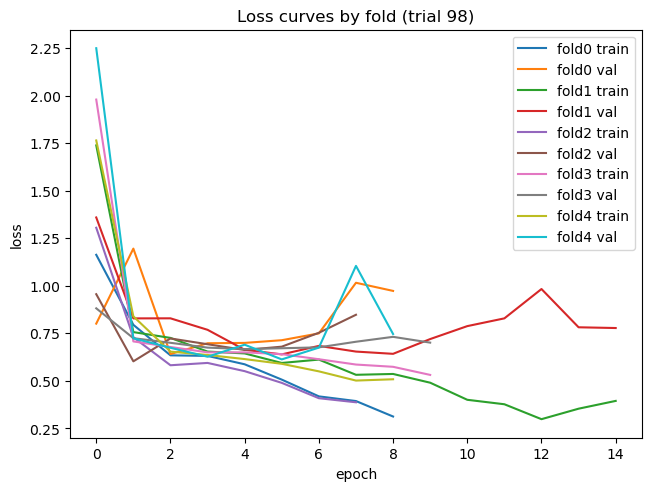

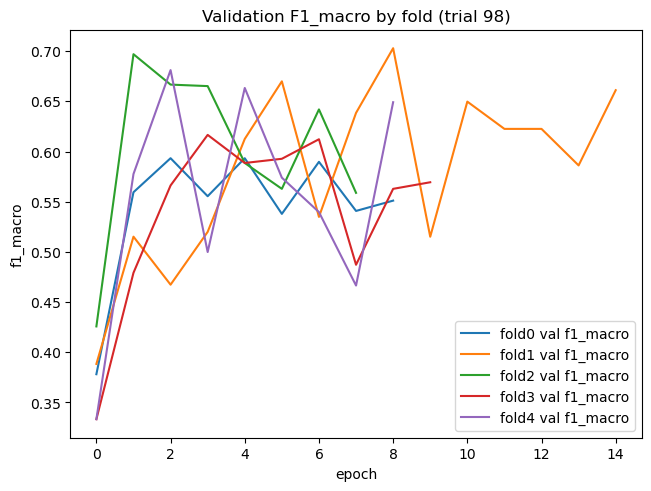

In [26]:
import matplotlib.pyplot as plt

# --- выбери trial по номеру (надёжнее, чем индекс в списке) ---
trial_number = 98
t = study.get_trials(deepcopy=False)[trial_number]  # если номера идут подряд, ок
# более надёжно, если есть пропуски:
# t = next(tr for tr in study.get_trials(deepcopy=False) if tr.number == trial_number)

print("Trial number:", t.number)
print("Values (f1, slope):", t.values)
print("Params:", t.params)

# --- новая номенклатура: fold_curves ---
fold_curves = t.user_attrs.get("fold_curves", None)

if fold_curves is not None and len(fold_curves) > 0:
    # 1) Loss curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        tr_losses = fc.get("train_losses", [])
        va_losses = fc.get("val_losses", [])
        if tr_losses:
            plt.plot(tr_losses, label=f"{name} train")
        if va_losses:
            plt.plot(va_losses, label=f"{name} val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves by fold (trial {t.number})")
    plt.legend()
    plt.show()

    # 2) F1 curves по фолдам
    plt.figure(constrained_layout=True)
    for fc in fold_curves:
        name = fc.get("split", "fold")
        va_f1s = fc.get("val_f1s", [])
        if va_f1s:
            plt.plot(va_f1s, label=f"{name} val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro by fold (trial {t.number})")
    plt.legend()
    plt.show()

else:
    # --- fallback: старая номенклатура ---
    train_losses = t.user_attrs.get("train_losses", [])
    val_losses   = t.user_attrs.get("val_losses", [])
    val_f1s      = t.user_attrs.get("val_f1s", [])

    plt.figure(constrained_layout=True)
    if train_losses:
        plt.plot(train_losses, label="train loss")
    if val_losses:
        plt.plot(val_losses, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"Loss curves (trial {t.number})")
    plt.legend()
    plt.show()

    plt.figure(constrained_layout=True)
    if val_f1s:
        plt.plot(val_f1s, label="val f1_macro")
    plt.xlabel("epoch")
    plt.ylabel("f1_macro")
    plt.title(f"Validation F1_macro (trial {t.number})")
    plt.legend()
    plt.show()



Trial number: 98
Values (f1, slope): [0.6811188811188811, -0.001977874504195264]
Params: {'lr': 0.0009052251021662693, 'weight_decay': 0.0016764247147362677, 'dropout': 0.3063576027936808, 'batch_size': 32, 'time_crop_on': 1, 'time_crop': 355}
